In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_parquet("data/flights_economy_1gb")

In [3]:
data.rename(columns={'travelDuration':"travelDurationMinutes"}, inplace=True)

In [4]:
data.columns

Index(['legId', 'searchDate', 'flightDate', 'startingAirport',
       'destinationAirport', 'numDaysToFlight', 'numLayovers',
       'layoverDurationMinutes', 'seatsRemaining', 'travelDurationMinutes',
       'totalTravelDistance', 'elapsedDays', 'isBasicEconomy', 'isRefundable',
       'isNonStop', 'baseFare', 'totalFare', 'segmentsDepartureTime',
       'segmentsArrivalTime', 'segmentsArrivalAirportCode',
       'segmentsDepartureAirportCode', 'segmentsAirlineName',
       'segmentsAirlineCode', 'segmentsAircraft', 'segmentsDurationInMinutes',
       'segmentsDistance', 'segmentsCabinCode'],
      dtype='str')

Seats 7: y = -0.3850x + 218.2350


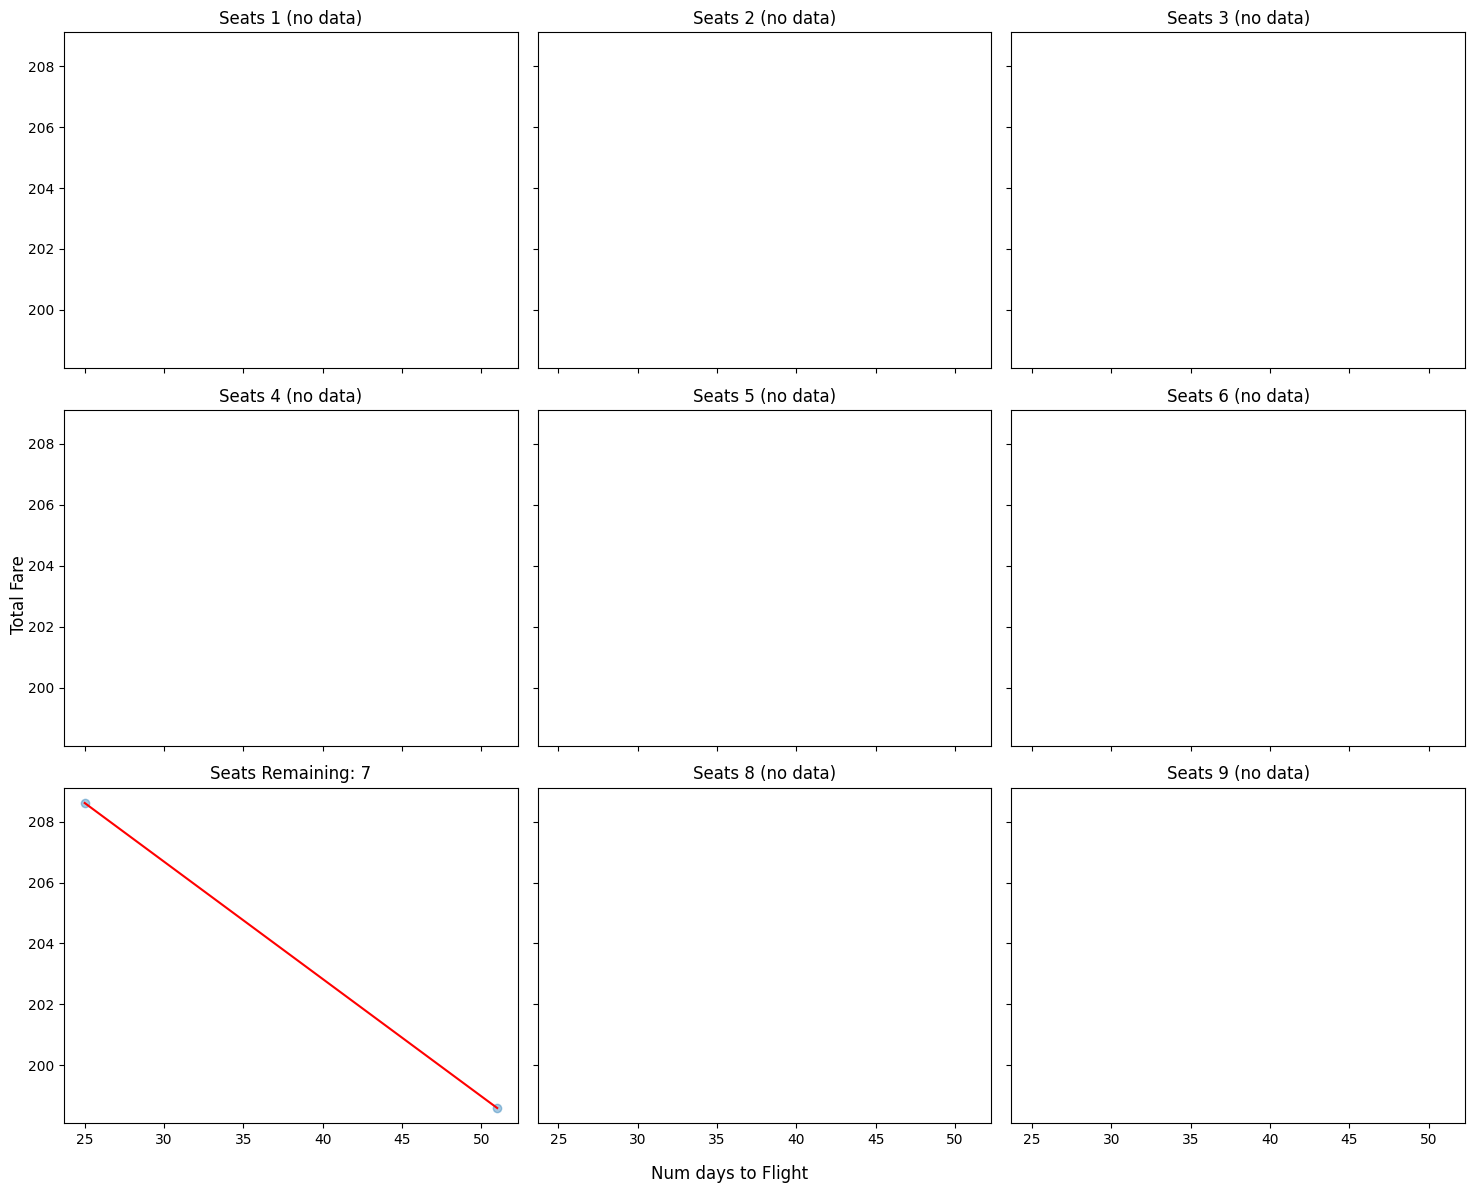

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, seats in enumerate(range(1, 10)):
    ax = axes[i]

    x = data[
        (data.startingAirport == 'LAX') &
        (data.destinationAirport == 'ATL') &
        (data.numLayovers == 0) &
        (data.segmentsAirlineCode.apply(lambda arr: all(code == "AA" for code in arr))) &
        (data.isBasicEconomy == True) &
        (data.seatsRemaining == seats)
    ]

    if len(x) < 2:
        ax.set_title(f"Seats {seats} (no data)")
        continue

    x_vals = x.numDaysToFlight.values
    y_vals = x.totalFare.values

    ax.scatter(x_vals, y_vals, alpha=0.4)

    # regression
    m, b = np.polyfit(x_vals, y_vals, 1)

    x_sorted = np.sort(x_vals)
    ax.plot(x_sorted, m*x_sorted + b, color="red")

    ax.set_title(f"Seats Remaining: {seats}")
    print(f"Seats {seats}: y = {m:.4f}x + {b:.4f}")

fig.supxlabel("Num days to Flight")
fig.supylabel("Total Fare")

plt.tight_layout()
plt.show()

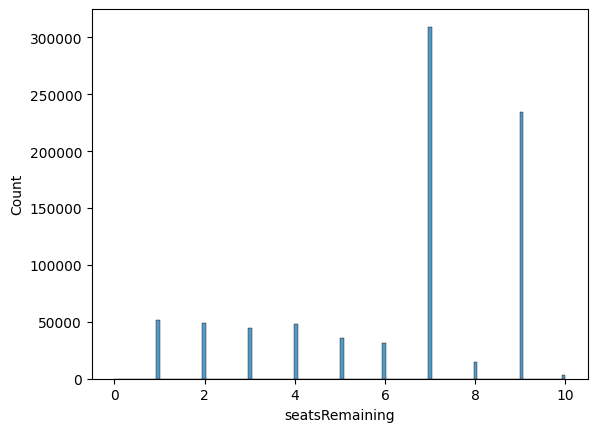

In [ ]:
sns.histplot(data.seatsRemaining)
plt.show()

In [32]:
x[x.totalFare > 1200].head()

,legId,searchDate,flightDate,startingAirport,destinationAirport,numDaysToFlight,numLayovers,layoverDurationMinutes,seatsRemaining,travelDurationMinutes,...,segmentsDepartureTime,segmentsArrivalTime,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsAirlineCode,segmentsAircraft,segmentsDurationInMinutes,segmentsDistance,segmentsCabinCode
81284,61bb5a78781b00e858f6b97e0de9d16d,2022-06-06,2022-06-18,LAX,BOS,12,0,0,1,339,...,[2022-06-18T16:56:00.000000000],[2022-06-18T22:35:00.000000000],[BOS],[LAX],[American Airlines],[AA],[AIRBUS INDUSTRIE A321 SHARKLETS],[339],[2606],[economy]
304898,cc87b475fae5e30ae4607f9921b14e9a,2022-05-21,2022-06-23,LAX,BOS,33,0,0,1,340,...,[2022-06-23T15:30:00.000000000],[2022-06-23T21:10:00.000000000],[BOS],[LAX],[American Airlines],[AA],[AIRBUS INDUSTRIE A321 SHARKLETS],[340],[2606],[economy]
409056,cc94676c3ccd4d29c7a589da9f8e8af9,2022-05-18,2022-06-10,LAX,BOS,23,0,0,4,339,...,[2022-06-10T16:56:00.000000000],[2022-06-10T22:35:00.000000000],[BOS],[LAX],[American Airlines],[AA],[AIRBUS INDUSTRIE A321 SHARKLETS],[339],[2606],[economy]
423209,57b4b6f366503a04b5b77ab3d2a015a2,2022-05-29,2022-06-25,LAX,BOS,27,0,0,5,340,...,[2022-06-25T15:30:00.000000000],[2022-06-25T21:10:00.000000000],[BOS],[LAX],[American Airlines],[AA],[AIRBUS INDUSTRIE A321 SHARKLETS],[340],[2606],[economy]
513042,f11461e63ab0c645d02aeb84b48d5161,2022-05-21,2022-06-13,LAX,BOS,23,0,0,1,334,...,[2022-06-13T22:00:00.000000000],[2022-06-14T03:34:00.000000000],[BOS],[LAX],[American Airlines],[AA],[AIRBUS INDUSTRIE A321 SHARKLETS],[334],[2606],[economy]


In [29]:
x.travelDurationMinutes.max()

np.int32(340)

In [12]:
data[data.numLayovers == 0].segmentsAirlineCode == "AA"

0          True
3          True
9          True
10         True
11        False
          ...  
821319     True
821320    False
821324     True
821325    False
821331    False
Name: segmentsAirlineCode, Length: 219152, dtype: bool

In [ ]:
sns.histplot(data.travelDuration, kde=True)
plt.show()

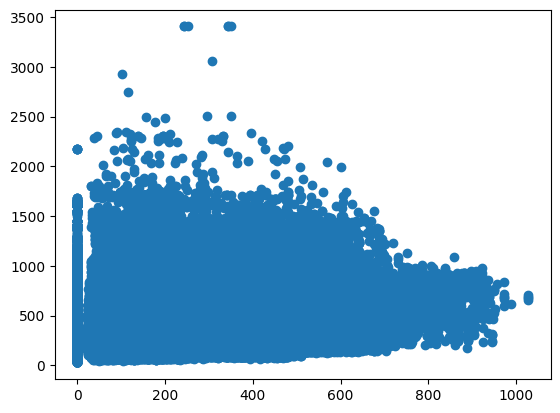

In [6]:
plt.scatter(data.layoverDurationMinutes, data.totalFare)
plt.show()

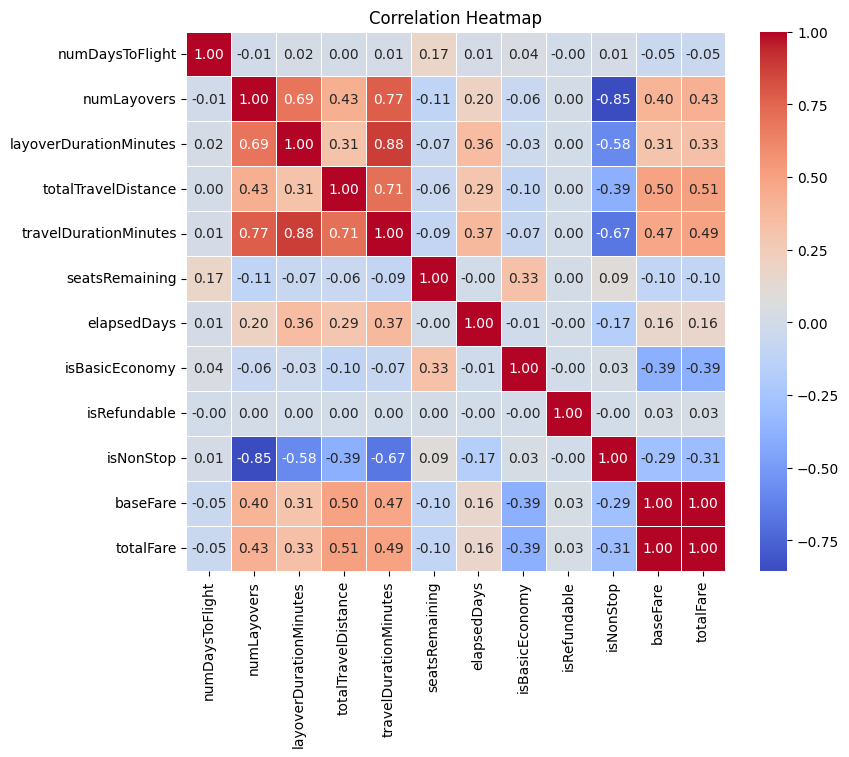

In [20]:
corr_cols = [
    "numDaysToFlight",
    "numLayovers",
    "layoverDurationMinutes",
    "totalTravelDistance",
    "travelDurationMinutes",
    "seatsRemaining",
    "elapsedDays",
    "isBasicEconomy",
    "isRefundable",
    "isNonStop",
    "baseFare",
    "totalFare",
]
plt.figure(figsize=(9, 7))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

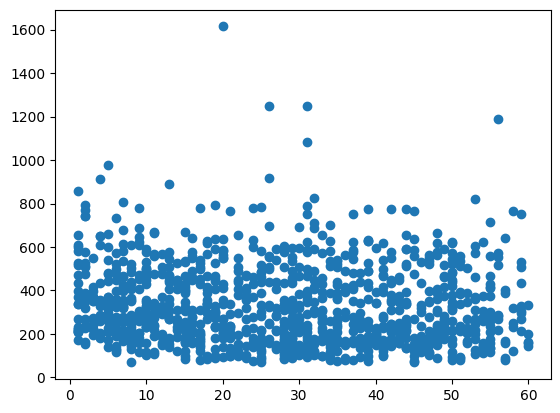

In [26]:
ds = data.sample(1000)

plt.scatter(ds.numDaysToFlight, ds.totalFare)
plt.show()

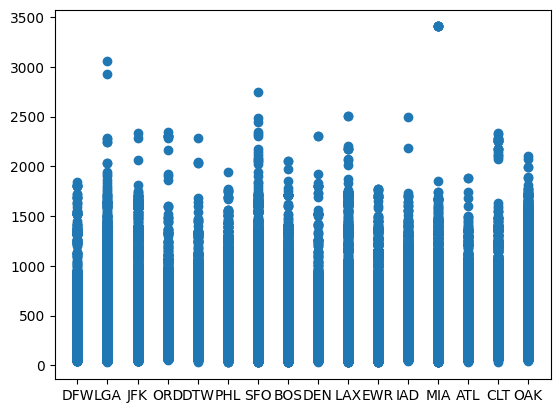

In [6]:
plt.scatter(data.startingAirport, data.totalFare)
plt.show()

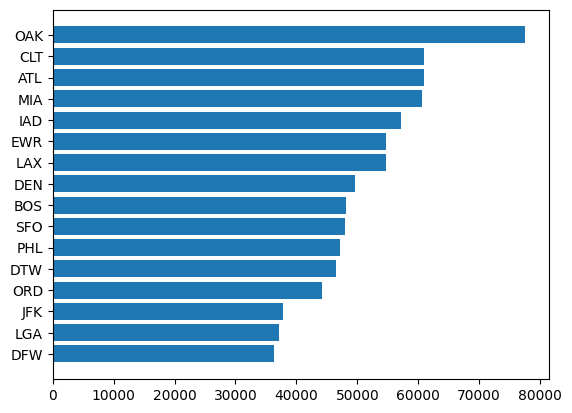

In [16]:
plt.barh(y=data.startingAirport.unique(), width=data.startingAirport.value_counts().sort_values())
# plt.xticks(rotation=90)
plt.show()

In [49]:
ap_start = "LGA"
ap_end = "EWR"

temp = data[
    (data.startingAirport == ap_start) &
    (data.destinationAirport == ap_end)
]

In [50]:
np.corrcoef(temp.numDaysToFlight, temp.totalFare)[0,1]

np.float64(nan)

In [44]:
np.corrcoef(data.numDaysToFlight, data.totalFare)[0,1]

np.float64(-0.05126467739220894)

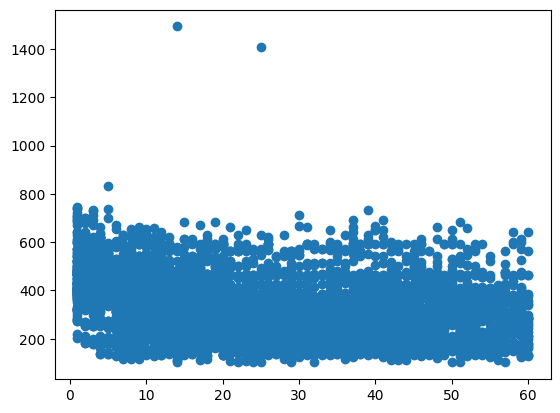

In [48]:
plt.scatter(temp.numDaysToFlight, temp.totalFare)
plt.show()

In [38]:
temp[temp.totalFare > 1500]

,legId,searchDate,flightDate,startingAirport,destinationAirport,numDaysToFlight,numLayovers,layoverDurationMinutes,seatsRemaining,travelDurationMinutes,...,segmentsDepartureTime,segmentsArrivalTime,segmentsArrivalAirportCode,segmentsDepartureAirportCode,segmentsAirlineName,segmentsAirlineCode,segmentsAircraft,segmentsDurationInMinutes,segmentsDistance,segmentsCabinCode
230033,ee56a6906307077e2681b34c971c2412,2022-05-29,2022-06-16,LAX,BOS,18,1,72,7,509,...,"[2022-06-16T14:00:00.000000000, 2022-06-16T20:...","[2022-06-16T19:47:00.000000000, 2022-06-16T22:...","[JFK, BOS]","[LAX, JFK]","[American Airlines, American Airlines]","[AA, AA]","[AIRBUS INDUSTRIE A321 SHARKLETS, Airbus A320]","[347, 90]","[2458, 185]","[economy, economy]"
801341,1c661271a485790ee1e72ebfd449e991,2022-07-20,2022-08-31,LAX,BOS,42,2,515,7,961,...,"[2022-09-01T01:55:00.000000000, 2022-09-01T06:...","[2022-09-01T03:09:00.000000000, 2022-09-01T11:...","[LAS, JFK, BOS]","[LAX, LAS, JFK]","[American Airlines, American Airlines, America...","[AA, AA, AA]","[Airbus A321, Airbus A321, Embraer 175]","[74, 291, 81]","[241, 2225, 185]","[economy, economy, economy]"


In [61]:
airports = data.startingAirport.unique()

corrs = []

for airport1 in airports:
    t = []
    for airport2 in airports:
        x = data[
                (data.startingAirport == airport1) &
                (data.destinationAirport == airport2)
            ]
        corr = np.corrcoef(x.numDaysToFlight, x.totalFare)
        if len(x) > 1:
            corr = np.corrcoef(x.numDaysToFlight, x.totalFare)
            t.append(corr[0, 1])
        else:
            t.append(np.nan)
    corrs.append(t)

/home/aryan-bodhe/Desktop/VSCode/IITH/Business Python/env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/home/aryan-bodhe/Desktop/VSCode/IITH/Business Python/env/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/aryan-bodhe/Desktop/VSCode/IITH/Business Python/env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/aryan-bodhe/Desktop/VSCode/IITH/Business Python/env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/aryan-bodhe/Desktop/VSCode/IITH/Business Python/env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= n

In [64]:
corrs
hm = pd.DataFrame(data=corrs, columns=airports)

In [76]:
hm.set_index('')

,DFW,LGA,JFK,ORD,DTW,PHL,SFO,BOS,DEN,LAX,EWR,IAD,MIA,ATL,CLT,OAK
,,,,,,,,,,,,,,,,
DFW,NaN,-0.016092,-0.003834,-0.094532,-0.257154,-0.052867,-0.076313,-0.141568,0.006371,-0.147848,0.011388,-0.116926,-0.231637,-0.074221,-0.144907,-0.070997
LGA,0.025182,NaN,NaN,-0.142626,-0.168346,-0.279981,0.062495,-0.270234,0.059495,0.066186,NaN,-0.180756,-0.014636,-0.122327,-0.435803,-0.006022
JFK,0.007866,NaN,NaN,0.046797,-0.132993,-0.269732,-0.014533,-0.084176,0.005552,0.002460,NaN,-0.207223,-0.014329,-0.081543,-0.108926,-0.079391
ORD,-0.055658,-0.128295,0.080333,NaN,-0.146454,-0.012106,-0.032363,0.005186,0.009092,-0.074953,-0.015392,-0.015813,-0.087490,-0.126740,-0.126226,-0.106460
DTW,-0.281635,-0.257695,-0.044168,-0.055326,NaN,-0.388868,-0.135615,-0.139288,0.004211,-0.140802,-0.234694,-0.158472,-0.172076,-0.408403,-0.454880,-0.045477
PHL,-0.010559,-0.326721,-0.304440,-0.080717,-0.406128,NaN,0.012149,-0.114320,-0.003839,0.033451,-0.143876,-0.348743,-0.067672,-0.060329,-0.063750,-0.001104
SFO,-0.025218,0.047948,-0.084500,-0.059637,-0.135960,-0.044785,NaN,0.051853,-0.056884,-0.016351,-0.064360,-0.150206,-0.036433,-0.190085,-0.040580,-0.101665
BOS,-0.068359,-0.233815,-0.058325,0.047940,-0.121174,-0.177105,0.100330,NaN,0.098571,0.051775,-0.096643,-0.029713,0.013424,-0.123382,-0.084138,0.040268
DEN,-0.024558,0.092123,0.004569,-0.020545,-0.029534,-0.063979,-0.115316,0.064368,NaN,-0.079004,0.103475,-0.012371,-0.077664,-0.034052,0.015956,-0.118332


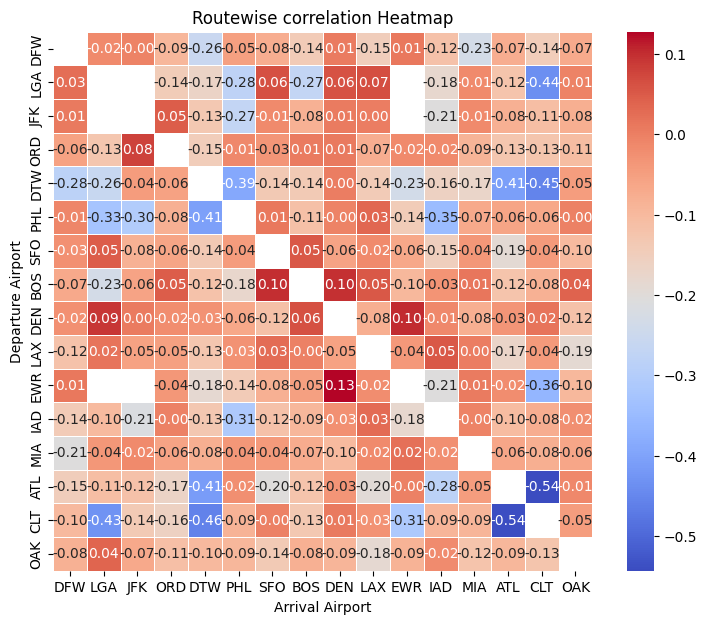

In [92]:
plt.figure(figsize=(9, 7))
sns.heatmap(hm.set_index(''), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Routewise correlation Heatmap")
plt.ylabel("Departure Airport")
plt.xlabel("Arrival Airport")
plt.show()

Correlation = -0.3487425807890892


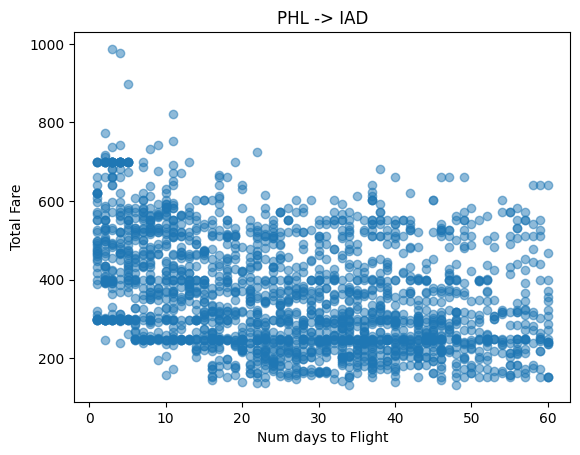

In [94]:
ap_start = "PHL"
ap_end = "IAD"

temp = data[
    (data.startingAirport == ap_start) &
    (data.destinationAirport == ap_end)
]

print("Correlation =", np.corrcoef(temp.numDaysToFlight, temp.totalFare)[0,1])
plt.title(f"{ap_start} -> {ap_end}")
plt.scatter(temp.numDaysToFlight, temp.totalFare, alpha=0.5)
plt.xlabel("Num days to Flight")
plt.ylabel("Total Fare")
plt.show()